# 06. Transparency Tools

## 📚 Learning Objectives

By completing this notebook, you will:
- Use transparency and interpretability tools
- Produce explanations and reports for stakeholders
- Integrate transparency into AI lifecycle

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME" — one explanation for one engineer; here the audience is a regulator and a customer, and the tools must be integrated.

**Used later in:** Course 11 (AIAT 125) — Unit 5 — the monitoring reports a deployed system has to produce.

---


# 06. Transparency Tools

## 🚨 THE PROBLEM: We Need Comprehensive Transparency Frameworks

**Remember the limitation from the previous notebook?**

We learned human-in-the-loop approaches for incorporating human judgment. But we discovered:

**How do we integrate all transparency tools into a comprehensive framework?**

**The Problem**: Comprehensive transparency also needs:
- ❌ **Integrated transparency tools** (combine all explanation methods)
- ❌ **Transparency frameworks** (systematic approach to transparency)
- ❌ **Tool comparison** (choose the right tool for each situation)
- ❌ **Complete transparency solutions** (end-to-end transparency)

**We've learned:**
- ✅ How to use SHAP, LIME, and counterfactuals (Notebooks 1-3)
- ✅ How to establish accountability (Notebook 4)
- ✅ How to implement HITL (Notebook 5)
- ✅ Individual transparency tools

**What you already learned in Course 01 (AIAT 111) — Unit 3, lesson 05 "Model Interpretability: SHAP and LIME":**
- ✅ A side-by-side comparison of what SHAP and LIME say about the same prediction

**What you have NOT done yet:**
- ❌ **Integrate** several methods into one transparency report
- ❌ Build a **transparency framework for a system**, not for a single model
- ❌ **Choose the right tool** for a given audience and a given legal duty

**We need transparency tools and frameworks** to:
1. Compare and integrate different explanation methods
2. Create comprehensive transparency frameworks
3. Choose the right tool for each situation
4. Build complete transparency solutions

**This notebook closes that gap.** Comparing two explainers you have already done (Course 01, Unit 3, lesson 05). Here you assemble several tools into one transparency framework for a whole system.

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding SHAP
- ✅ **Example 2: LIME Explanations** - Understanding LIME
- ✅ **Example 3: Counterfactual Analysis** - Understanding counterfactuals
- ✅ **Example 4: Accountability Frameworks** - Understanding accountability
- ✅ **Example 5: HITL Approaches** - Understanding human oversight
- ✅ **Basic Python knowledge**: Functions, data manipulation

**If you haven't completed these**, you might struggle with:
- Understanding how to compare transparency tools
- Knowing which tool to use when
- Understanding transparency frameworks

---

## 🔗 Where This Notebook Fits

**This is the SIXTH core example in Unit 4** - it teaches you comprehensive transparency! (One hands-on practice notebook, 07, follows before you move on to Unit 5.)

**Why this example LAST?**
- **Before** you can integrate tools, you need to understand individual tools (Examples 1-3)
- **Before** you can build frameworks, you need accountability and HITL (Examples 4-5)
- **Before** you can deploy systems, you need comprehensive transparency

**Builds on**: 
- 📓 Example 1: SHAP Explanations (explainability)
- 📓 Example 2: LIME Explanations (local explanations)
- 📓 Example 3: Counterfactual Analysis ("what if" scenarios)
- 📓 Example 4: Accountability Frameworks (accountability)
- 📓 Example 5: HITL Approaches (human oversight)

**Leads to**: 
- 📓 Unit 5: Governance and Regulations (next unit in the course!)

**Why this order?**
1. Transparency tools provide **comprehensive framework** (needed after learning all tools)
2. Transparency tools teach **tool selection** (critical for practical application)
3. Transparency tools show **complete solutions** (essential for deployment)

---

## The Story: Complete Transparency

Imagine you're building an AI system. **Before** comprehensive transparency, you'd have individual tools but wouldn't know how to integrate them (fragmented!). **After** using transparency frameworks, you have a systematic approach - compare tools, choose the right one, integrate everything - complete transparency!

Same with AI: **Before** we have individual transparency tools but no framework, now we learn transparency tools - compare methods, create frameworks, build complete solutions! **After** transparency tools, we have comprehensive transparent AI systems!

---

## Why Transparency Tools Matter

Transparency tools are essential for ethical AI:
- **Integration**: Combine all explanation methods into frameworks
- **Selection**: Choose the right tool for each situation
- **Completeness**: Build end-to-end transparency solutions
- **Trust**: Build user confidence through comprehensive transparency
- **Compliance**: Meet transparency requirements systematically

## Learning Objectives
1. Compare different transparency tools
2. Understand when to use each tool
3. Create transparency frameworks
4. Integrate explanation methods
5. Build comprehensive transparency solutions
6. Evaluate transparency tool effectiveness

## 📌 The case: model cards stopped being a courtesy and became a legal obligation

When Mitchell et al. proposed **Model Cards for Model Reporting** (FAT\* 2019), they were
proposing a *norm*: a short document stating what a model is for, what it is not for, what
data trained it, and — the section everyone skips — **evaluation disaggregated by group**.
Voluntary. A good idea some teams adopted.

Five years later it is law. The **EU AI Act (Regulation (EU) 2024/1689)** requires providers of
high-risk AI systems to draw up **technical documentation** before placing the system on the
market (Article 11 and Annex IV) and to supply **instructions for use** stating the system's
intended purpose, its known limitations and its performance characteristics (Article 13). The
high-risk obligations apply from **2 August 2026**, and failing them carries administrative
fines of up to **€15 million or 3 % of worldwide annual turnover** (Article 99).

Now connect that to Unit 2. The three systems audited in *Gender Shades* were bought on a
single headline accuracy figure; measured overall on the audit's benchmark they erred on
6.3 %, 10.0 % and 12.1 % of faces. The disaggregated numbers, which the audit produced in an
afternoon, reached **34.7 %** for darker-skinned women. **The disaggregated-evaluation
section of a model card is exactly the artefact that would have made that visible before
shipping**, without an external auditor and without a press cycle.

**The WHY — what goes wrong without a shipping artefact.** Notebooks 01–05 each built a tool
that answers one question for one audience. If none of it leaves your laptop, none of it is
transparency. A model card is the one document that a procurement officer, a regulator, a
journalist and the next engineer can all read — and the discipline of filling in
"out-of-scope use" and "fairness evaluation" is what forces a team to notice the fields it
cannot honestly complete.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` - 891 real passengers. Six real,
  interpretable features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `is_female`)
  and the real recorded outcome, `Survived`.
- This is deliberately the same model Unit 2 audited for fairness, so the
  explanations here can be checked against those findings.

**Outputs:** What you'll see when you run the cells

- A model card for the real survival model, filled in from measured values
- A **real** fairness section in that card, carrying the Unit 2 numbers rather
  than the usual "fairness not evaluated" placeholder

---

## Part 1: Choosing and Combining Transparency Tools

Notebooks 01-05 each built one tool. A *transparency framework* is knowing **which tool
answers which question** - and shipping the artifacts (like a model card) that put the
answers in front of stakeholders.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Why a toolbox view: transparency is not one tool - each audience asks a
# different question, and each tool from this unit answers exactly one of them.

# Step 1: The toolbox - which tool answers which question?
import pandas as pd

# One row per tool taught in this unit: the question it answers, for whom, at what scope.
toolbox = pd.DataFrame([
    ['SHAP (Nb. 01)',            'Why this prediction? (additive attributions)',
     'Developers, auditors',     'Global + local'],
    ['LIME (Nb. 02)',            'Why this prediction? (fast local rules)',
     'Developers, support staff','Local'],
    ['Counterfactuals (Nb. 03)', 'What would change the outcome?',
     'Affected individuals',     'Local'],
    ['Audit trails (Nb. 04)',    'What happened, when, who signed off?',
     'Auditors, regulators',     'System-level'],
    ['HITL routing (Nb. 05)',    'Which decisions need a human?',
     'Operations, compliance',   'System-level'],
    ['Model cards (this Nb.)',   'What is this model, and its limits?',
     'Everyone',                 'Global'],
], columns=['Tool', 'Question it answers', 'Main audience', 'Scope'])

print("TRANSPARENCY TOOLBOX")
print("=" * 100)
print(toolbox.to_string(index=False))
print("\nRule of thumb: individuals need counterfactuals, regulators need audit")
print("trails and model cards, developers need SHAP/LIME while debugging.")

TRANSPARENCY TOOLBOX
                    Tool                          Question it answers             Main audience          Scope
           SHAP (Nb. 01) Why this prediction? (additive attributions)      Developers, auditors Global + local
           LIME (Nb. 02)      Why this prediction? (fast local rules) Developers, support staff          Local
Counterfactuals (Nb. 03)               What would change the outcome?      Affected individuals          Local
   Audit trails (Nb. 04)         What happened, when, who signed off?      Auditors, regulators   System-level
   HITL routing (Nb. 05)                Which decisions need a human?    Operations, compliance   System-level
  Model cards (this Nb.)          What is this model, and its limits?                  Everyone         Global

Rule of thumb: individuals need counterfactuals, regulators need audit
trails and model cards, developers need SHAP/LIME while debugging.


In [3]:
# Why model cards: they are the shipping artifact of transparency - the one
# document every stakeholder can read before trusting (or rejecting) a model.

# Step 2: Generate a model card - the shipping artifact of transparency
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Train the model this card describes (same real setup as Notebooks 01-03)
df = load("titanic")
age_median = df['Age'].median()
n_age_missing = int(df['Age'].isna().sum())
n_embarked_missing = int(df['Embarked'].isna().sum())
df['Age'] = df['Age'].fillna(age_median)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),
    'Age':       df['Age'].astype(float),
    'SibSp':     df['SibSp'].astype(float),
    'Parch':     df['Parch'].astype(float),
    'Fare':      df['Fare'].astype(float),
    'is_female': (df['Sex'] == 'female').astype(float),
})
y = df['Survived'].values
group = df['Sex'].values
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, group, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42).fit(X_train, y_train)
pred = model.predict(X_test)
test_acc = accuracy_score(y_test, pred)

# MEASURE the fairness numbers rather than writing "not evaluated".
# This is the whole point: a model card is only worth reading if its claims
# were computed, and we can compute them because the data is real.
per_group = {}
for g in sorted(set(g_test)):
    mask = (g_test == g)
    per_group[g] = {'n': int(mask.sum()),
                    'accuracy': accuracy_score(y_test[mask], pred[mask]),
                    'positive_rate': pred[mask].mean(),
                    'base_rate': y_test[mask].mean()}
acc_gap = (max(v['accuracy'] for v in per_group.values())
           - min(v['accuracy'] for v in per_group.values()))
dp_gap = (max(v['positive_rate'] for v in per_group.values())
          - min(v['positive_rate'] for v in per_group.values()))
fairness_lines = "; ".join(
    f"{g}: acc {v['accuracy']:.3f}, predicted-positive rate {v['positive_rate']:.3f} (n={v['n']})"
    for g, v in per_group.items())

# The card answers the standard questions: intended use, data, evaluation,
# fairness, oversight, limitations - and is HONEST about what was not done.
model_card = {
    'Model name / version': 'titanic-survival-rf v1.0 (course demo)',
    'Intended use': 'Teaching example for XAI and transparency methods only',
    'Out-of-scope use': 'Any decision about a real person; any production use',
    'Training data': f'{len(X_train)} real passenger records from the Titanic '
                     f'manifest (891 total). Real historical people, not synthetic.',
    'Known data quality issues': f'{n_age_missing} of 891 ages and '
                                 f'{n_embarked_missing} ports were missing in the '
                                 f'source; imputed with median ({age_median:.1f}) '
                                 f'and mode respectively. Cabin (687 missing) unused.',
    'Evaluation': f'Accuracy {test_acc:.3f} on {len(X_test)} held-out passengers',
    'Fairness evaluation': f'PERFORMED on sex. {fairness_lines}. '
                           f'Per-group accuracy gap {acc_gap:.3f}; '
                           f'predicted-positive-rate gap {dp_gap:.3f}.',
    'Explainability': 'SHAP + LIME + counterfactuals in Notebooks 01-03. SHAP ranks '
                      'the protected attribute (sex) as the single most influential '
                      'feature - documented here deliberately, not buried.',
    'Human oversight': 'Confidence-based HITL routing recommended (Notebook 05); '
                       'note that the routing rule itself defers groups unequally.',
    'Known limitations': 'Trained on a single 1912 event; the model response to Fare '
                         'is non-monotonic (Notebook 03), so its counterfactuals are '
                         'not reliable recourse. No temporal drift handling.',
    'Contact / accountable owner': 'course-instructor (RACI: see Notebook 04)',
}

print("MODEL CARD")
print("=" * 80)
for k, v in model_card.items():
    print(f"{k:>28}: {v}")

print("\n" + "="*80)
print("WHAT MAKES THIS CARD DIFFERENT")
print("="*80)
print("Most teaching model cards contain the line 'fairness not yet evaluated'.")
print("This one does not, because the model was trained on real people and the")
print("fairness numbers could actually be computed. Read the fairness row again:")
for g, v in per_group.items():
    print(f"   {g:<8}: accuracy {v['accuracy']:.3f}, model predicts survival "
          f"{v['positive_rate']:.1%} of the time, history recorded "
          f"{v['base_rate']:.1%}")
# Point the reader at whichever gap is actually the large one in this run.
if dp_gap >= acc_gap:
    print(f"\nA reviewer can now ask a specific question - 'the per-group accuracy")
    print(f"gap is only {acc_gap:.3f}, but the model predicts survival at rates")
    print(f"{dp_gap:.3f} apart across the two groups: is that difference justified")
    print(f"by the task?' - instead of a vague one.")
else:
    print(f"\nA reviewer can now ask a specific question - 'why is the per-group")
    print(f"accuracy gap {acc_gap:.3f}?' - instead of a vague one.")
print("That is the entire function of a model card: to make the uncomfortable")
print("questions askable BEFORE deployment, in terms specific enough to answer.")
print("\nTemplate: Mitchell et al. 2019, 'Model Cards for Model Reporting'.")

titanic: full file, 891 rows.
MODEL CARD
        Model name / version: titanic-survival-rf v1.0 (course demo)
                Intended use: Teaching example for XAI and transparency methods only
            Out-of-scope use: Any decision about a real person; any production use
               Training data: 668 real passenger records from the Titanic manifest (891 total). Real historical people, not synthetic.
   Known data quality issues: 177 of 891 ages and 2 ports were missing in the source; imputed with median (28.0) and mode respectively. Cabin (687 missing) unused.
                  Evaluation: Accuracy 0.789 on 223 held-out passengers
         Fairness evaluation: PERFORMED on sex. female: acc 0.775, predicted-positive rate 0.637 (n=80); male: acc 0.797, predicted-positive rate 0.168 (n=143). Per-group accuracy gap 0.022; predicted-positive-rate gap 0.470.
              Explainability: SHAP + LIME + counterfactuals in Notebooks 01-03. SHAP ranks the protected attribute (sex) as t

## Part 2: Why the disaggregated section is the one that matters

The card above reports two disaggregated numbers: a per-group **accuracy** gap and a per-group
**predicted-positive-rate** gap. They are not the same size, and they are not close. Drawing
them on one scale shows why *Gender Shades* needed an external audit to find what a
disaggregated card could have shown in an afternoon — and why the choice of which metric to
disaggregate is itself the disclosure decision.

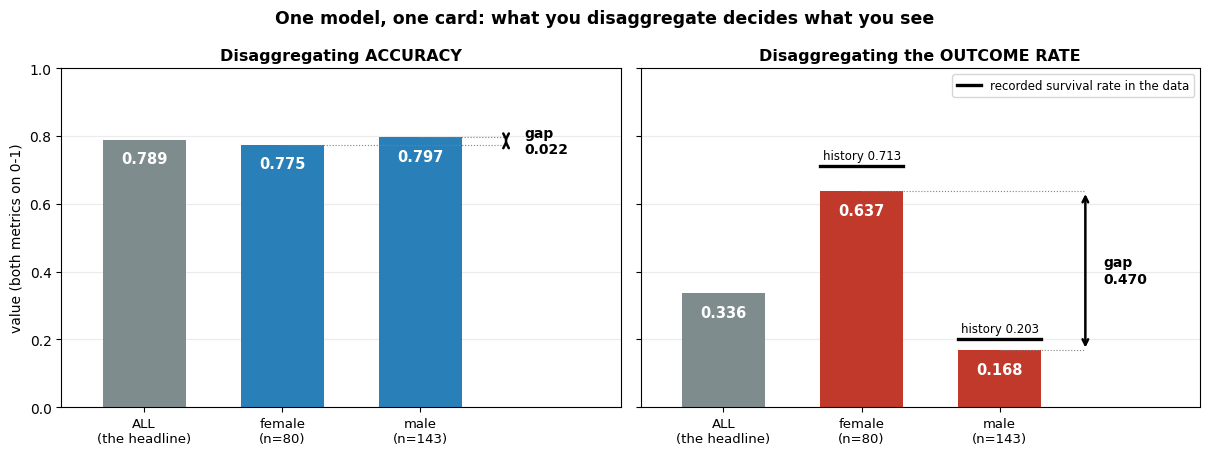

Per-group ACCURACY gap        : 0.022
Per-group OUTCOME-RATE gap    : 0.470   (21x larger)

A card that disaggregates only accuracy reports a 0.022 gap and
passes review. The same model, on the same test set, predicts survival for
63.7% of one group and 16.8% of the other.
Both sentences are true. Only one of them is informative, and the card
format does not choose for you - the team filling it in does.


In [4]:
# WHY this figure: a model card can be complete, honest and still hide the
# problem, because a headline number is an average and only ONE of the metrics
# we disaggregate actually moves. We plot both on the same 0-1 scale so the two
# gap arrows can be compared by eye.
import matplotlib.pyplot as plt

groups = list(per_group.keys())
labels = ['ALL\n(the headline)'] + [f"{g}\n(n={per_group[g]['n']})" for g in groups]
overall_pos_rate = float(pred.mean())

panels = [
    ('accuracy', 'Disaggregating ACCURACY',
     [test_acc] + [per_group[g]['accuracy'] for g in groups], acc_gap, '#2980b9'),
    ('positive_rate', 'Disaggregating the OUTCOME RATE',
     [overall_pos_rate] + [per_group[g]['positive_rate'] for g in groups],
     dp_gap, '#c0392b'),
]

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6), sharey=True)
for ax, (key, title, values, gap, colour) in zip(axes, panels):
    bars = ax.bar(range(3), values, width=0.6,
                  color=['#7f8c8d', colour, colour])
    # Labels go INSIDE the bars: on the right-hand panel the space just above a
    # bar is taken by the recorded-rate mark, and a label there would sit on it.
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v - 0.035, f"{v:.3f}",
                ha='center', va='top', fontsize=10.5, color='white',
                fontweight='bold')
    # A double-headed arrow between the two GROUP bars, drawn to scale. The
    # length of this arrow is the entire point of the figure.
    v_lo, v_hi = sorted(values[1:])
    ax.annotate('', xy=(2.62, v_lo), xytext=(2.62, v_hi),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.8))
    ax.plot([1, 2.62], [values[1]] * 2, color='0.5', lw=0.8, ls=':')
    ax.plot([2, 2.62], [values[2]] * 2, color='0.5', lw=0.8, ls=':')
    ax.text(2.75, (v_lo + v_hi) / 2, f"gap\n{gap:.3f}", va='center',
            ha='left', fontsize=10, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(labels, fontsize=9.5)
    ax.set_xlim(-0.6, 3.45)
    ax.set_ylim(0, 1.0)
    ax.set_title(title, fontsize=11.5, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)

axes[0].set_ylabel('value (both metrics on 0-1)')
# On the outcome-rate panel, show what history actually recorded, so the student
# can see the model is tracking the record rather than inventing the gap.
for k, g in enumerate(groups, start=1):
    br = per_group[g]['base_rate']
    axes[1].plot([k - 0.3, k + 0.3], [br] * 2, color='black', lw=2.4,
                 label='recorded survival rate in the data' if k == 1 else None)
    axes[1].text(k, br + 0.018, f"history {br:.3f}", ha='center', fontsize=8.5)
axes[1].legend(fontsize=8.5, loc='upper right')

fig.suptitle('One model, one card: what you disaggregate decides what you see',
             fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Per-group ACCURACY gap        : {acc_gap:.3f}")
print(f"Per-group OUTCOME-RATE gap    : {dp_gap:.3f}   "
      f"({dp_gap / acc_gap:.0f}x larger)")
print(f"\nA card that disaggregates only accuracy reports a {acc_gap:.3f} gap and")
print("passes review. The same model, on the same test set, predicts survival for")
print(f"{per_group[groups[0]]['positive_rate']:.1%} of one group and "
      f"{per_group[groups[1]]['positive_rate']:.1%} of the other.")
print("Both sentences are true. Only one of them is informative, and the card")
print("format does not choose for you - the team filling it in does.")

**Read the figure.** Both panels use the same 0–1 axis and the same three bars: the headline
number in grey, then the two groups.

*Left.* Per-group **accuracy** — 0.775 for women, 0.797 for men. The black double arrow between
the two group bars is the gap, and it is **0.022**: so short it is barely a mark on the axis.
A model card that disaggregates accuracy and stops there reports a gap of two percentage
points and passes review.

*Right.* The same model, the same test set, now showing how often it **predicts survival** —
**0.637** of women against **0.168** of men. The arrow between those two bars is drawn on the
identical scale and is **0.470**: about **21×** the accuracy gap. The black horizontal marks
are the survival rates history actually recorded (**0.713** and **0.203**), there so you can
see the model is tracking the record rather than inventing the disparity.

**What this proves.** Not that the model is broken — the two panels describe the same
predictions. It proves that *which* metric a card disaggregates decides whether anything is
visible at all, and that a complete, honest, accuracy-only card can be completely
uninformative. That is the *Gender Shades* lesson in one picture: those systems reported
headline error rates of 6.3–12.1% and the harm was at 34.7%, and nothing in the format of a
document forces the team to compute the number that would have shown it.

## 💬 Discuss

The card your run generated is filled from **measured** values, including the section most
model cards leave blank: *Fairness evaluation: PERFORMED on sex — female acc 0.775,
predicted-positive rate 0.637 (n=80); male acc 0.797, rate 0.168 (n=143); per-group accuracy
gap 0.022*. It also records what the data-quality section usually hides: **177 of 891 ages
imputed with the median**.

1. **Who is the card for, and does one document serve them?** The toolbox table above lists
   six audiences — developers, auditors, affected individuals, regulators, operations,
   everyone. A regulator wants Annex IV completeness; a rejected applicant wants a sentence
   they can act on; a procurement officer wants a number to compare. Can one artefact serve
   all three, or does honest transparency require several documents that must then be kept
   consistent? Say which you would build, and who maintains it.
2. **A card that admits a fairness gap is a card a competitor will quote.** Your card
   discloses a per-group accuracy gap and a predicted-positive-rate gap of about 0.47. A
   vendor who runs no fairness evaluation writes "not evaluated" and looks cleaner in a
   tender. Does mandatory documentation solve that, given that the AI Act requires the
   document rather than a particular result? What would you add to a tender scoring sheet to
   stop the honest vendor losing?
3. **Would a model card have caught Gender Shades?** Argue it. The disaggregated-evaluation
   section demands per-group numbers — but the team choosing the groups is the team that did
   not think to disaggregate, and *Gender Shades* found the harm at the **intersection** of
   skin type and gender, not on either axis alone. Does the card format have to mandate
   intersectional cells, and if so, who decides which ones?


---

## ➡️ Transition to Unit 5: Governance and Regulations

### What We've Accomplished

We've completed the six core examples of Unit 4: Transparency and Accountability! (Notebook 07 offers extra hands-on SHAP/LIME practice - do it before starting Unit 5.) We've learned:
- ✅ How to explain AI decisions (SHAP, LIME, counterfactuals)
- ✅ How to establish accountability frameworks
- ✅ How to implement human-in-the-loop approaches
- ✅ How to build comprehensive transparency solutions

### The Next Challenge: Governance and Regulations

**Transparency and accountability are important, but they're not the only ethical concerns!**

As we build AI systems, we also need to consider:
- **Governance**: How do we govern AI development and deployment?
- **Regulations**: What laws and regulations apply to AI?
- **Compliance**: How do we comply with AI regulations?
- **Legal Challenges**: What legal issues arise with AI?

**The Problem**: We've learned about transparency and accountability, but **AI systems also raise governance and regulatory concerns**:
- AI systems must comply with laws and regulations
- AI systems need governance frameworks
- AI systems face legal challenges
- AI systems require regulatory compliance

**This is exactly what we'll learn in Unit 5: Governance and Regulations!**

---

## ➡️ Next Steps

**You've completed Unit 4!** Now you understand:
- ✅ How to explain AI decisions
- ✅ How to ensure accountability
- ✅ How to build transparent AI systems

**Next Unit**: `unit5-governance-regulations/`
- Learn about global AI regulations
- Understand industry-specific regulations
- Master governance frameworks
- Navigate legal challenges in AI

**Congratulations!** 🎉 You've completed Unit 4 and learned how to build transparent and accountable AI systems!

## ⚠️ Where this breaks

- **A document is not a property of a system.** A model card describes what its authors chose
  to measure and chose to write down. Nothing in the format prevents a card that is accurate,
  complete, well formatted and describes a model that should never have been built. Unit 1
  is where that question lives.
- **"Fairness evaluated" is a checkbox, and the checkbox does not carry the caveats.** Your
  card says fairness was evaluated on **sex** — one attribute, one test split, group sizes
  n=80 and n=143. It does not say the metrics disagreed (Unit 2, Notebook 01), that the
  disparity is partly a stated historical policy, or that n=80 makes the estimate noisy. A
  reader who sees "PERFORMED" and moves on has been misled by an honest card.
- **Cards go stale silently.** They describe the model at a point in time. Retrain, change a
  threshold, or let the input population drift, and the card is now wrong while still looking
  authoritative. Version the card with the model, or it becomes a liability.
- **Disaggregation only finds the groups you thought of.** *Gender Shades* is the proof: both
  single-axis views were acceptable and the harm lived in the intersection. A card format
  cannot generate the hypothesis for you.
- **Documentation duties do not mandate outcomes.** The AI Act requires you to *state*
  performance and limitations; it does not require any particular fairness number. Compliance
  and quality are different axes, and a fully compliant card can document a poor system.
- **Transparency has costs.** Publishing intended and out-of-scope uses, training-data
  provenance and per-group performance can expose commercial information, help an adversary
  probe the model (Unit 3, Notebook 05), and create legal exposure. Those are real trade-offs,
  not reasons to skip it — but pretending they do not exist is how transparency programmes
  lose internal arguments.

**The cheaper alternative when a full card is disproportionate:** a **datasheet for the
dataset** (Gebru et al., 2018) is often the higher-value document, because most of the
failures in this course originate in the data — the label (Obermeyer), the sample
(*Gender Shades*), or the missingness (177 imputed ages, right here in your own card).


## 🔭 State of the field (2026)

Model cards won the argument - they are now a procurement and regulatory expectation rather than a
courtesy - but two things changed around them. First, publishing a card is not the same as filling it
in: a systematic analysis of 32,000 Hugging Face model cards found the limitations, evaluation and
environmental-impact sections to be the least completed of all, while the training section was the most
(Liang et al., 2024, arXiv:2402.05160). That is precisely the disaggregated section you wrote in Part 1,
and it is the section people skip. Second, the card alone no longer covers the reporting surface: 2026
practice adds an *evaluation* card, an interpretive layer documenting how a benchmark number was
produced so a reader can judge what it does and does not license (Ghosh et al., 2026, arXiv:2606.09809).

Write the card first. It is the single artefact regulators, procurement, and Course 11's monitoring
reports all read, and its disaggregated section is what turns a headline accuracy into a claim you can
defend - as the two panels in Part 2 showed, an equal-accuracy model can still select 63.7% of women
and 16.8% of men. Unit 5 takes this into the governance regime; the card itself is what the official
plan examines.

## 📚 References

1. Doshi-Velez, F. & Kim, B. (2017). *Towards A Rigorous Science of Interpretable Machine Learning*. <https://arxiv.org/abs/1702.08608>
2. Mitchell, M., Wu, S., Zaldivar, A., et al. (2019). *Model Cards for Model Reporting*. FAT* 2019. <https://arxiv.org/abs/1810.03993>
3. Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
4. Barredo Arrieta, A., Díaz-Rodríguez, N., Del Ser, J., et al. (2020). *Explainable Artificial Intelligence (XAI): Concepts, Taxonomies, Opportunities and Challenges toward Responsible AI*. Information Fusion, 58. <https://arxiv.org/abs/1910.10045>
5. Liang, W., Rajani, N., Yang, X., Ozoani, E., Wu, E., Chen, Y., Smith, D. S. & Zou, J. (2024). *What's documented in AI? Systematic Analysis of 32K AI Model Cards*. <https://arxiv.org/abs/2402.05160>
6. Ghosh, A., Reuel, A., Chim, J., Kennedy, W. M., Yadav, S., Mickel, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. <https://arxiv.org/abs/2606.09809>
